In [88]:
import numpy as np
from scipy import sparse


def h2plus_potential_matrix_3d(N, epsilon=1e-2, L=15.0, x_min=None, x_max=None):
    """
    Build the sparse diagonal potential operator for H2+ in the position basis.

    Physics model used here (atomic units):
        V(x,y,z) = -1/sqrt((x+0.7)^2 + y^2 + z^2 + epsilon^2)
                 - 1/sqrt((x-0.7)^2 + y^2 + z^2 + epsilon^2)

    The two nuclei are fixed at x = -0.7 and x = +0.7 (bond length 1.4 a0).

    Parameters
    ----------
    N : int
        Number of grid points along each Cartesian axis.
    epsilon : float
        Softening parameter used to avoid divergence exactly at nucleus positions.
    L : float
        Domain length if explicit bounds are not supplied.
        If used, the domain is [-L/2, +L/2].
    x_min, x_max : float or None
        Explicit domain bounds for x (and also used for y and z).

    Returns
    -------
    V : scipy.sparse.csr_matrix
        Sparse diagonal matrix with shape (N^3, N^3).
    v_diag : np.ndarray
        Flattened diagonal values of V in C-order.
    xyz : np.ndarray
        1D coordinate grid used for x, y, and z.
    """
    # Validate basic input constraints.
    if N < 1:
        raise ValueError("N must be >= 1")
    if epsilon < 0:
        raise ValueError("epsilon must be >= 0")

    # If user did not provide explicit bounds, use symmetric box of size L.
    if x_min is None or x_max is None:
        x_min = -0.5 * L
        x_max = 0.5 * L

    # Build uniform 1D axis and then 3D Cartesian grid with ij indexing.
    # With indexing='ij', axis order is X[i,j,k], Y[i,j,k], Z[i,j,k].
    xyz = np.linspace(x_min, x_max, N)
    X, Y, Z = np.meshgrid(xyz, xyz, xyz, indexing="ij")

    # Evaluate electron-proton attraction from both nuclei on every grid point.
    # Negative sign is essential for attractive Coulomb potential.
    V_xyz = (
        -1.0 / np.sqrt((X + 0.7) ** 2 + Y ** 2 + Z ** 2 + epsilon ** 2)
        - 1.0 / np.sqrt((X - 0.7) ** 2 + Y ** 2 + Z ** 2 + epsilon ** 2)
    )

    # Flatten in C-order to match standard linear index mapping:
    # m = k + N*j + N^2*i.
    v_diag = V_xyz.ravel(order="C")

    # Build sparse diagonal matrix representation of the potential operator.
    V = sparse.diags(v_diag, offsets=0, format="csr")
    return V, v_diag, xyz


In [89]:
import numpy as np
from scipy import sparse

# Atomic-unit constants used in kinetic-energy prefactor.
hbar = 1.0
m = 1.0


def T1D_sparse(N, x_min=-7.5, x_max=7.5, hbar=1.0, m=1.0):
    """Build the 1D finite-difference kinetic operator as sparse CSR."""
    # Need at least two points to define a finite-difference stencil.
    if N < 2:
        raise ValueError("N must be >= 2")

    # Uniform grid spacing over [x_min, x_max].
    dx = (x_max - x_min) / (N - 1)

    # Kinetic operator for 1D: -(hbar^2/2m) * d2/dx2.
    # Discrete Laplacian stencil is [1, -2, 1] / dx^2.
    pref = -(hbar**2) / (2.0 * m * dx**2)
    main = -2.0 * np.ones(N)
    off = np.ones(N - 1)
    return sparse.diags([off, main, off], offsets=[-1, 0, 1], format="csr") * pref


def T3D_sparse(N, x_min=-7.5, x_max=7.5, hbar=1.0, m=1.0):
    """Build 3D kinetic operator using Kronecker-sum structure."""
    # Start from 1D kinetic operator and 1D identity.
    T = T1D_sparse(N, x_min=x_min, x_max=x_max, hbar=hbar, m=m)
    I = sparse.eye(N, format="csr")

    # 3D operator = T_x + T_y + T_z in tensor-product basis.
    return (
        sparse.kron(sparse.kron(T, I, format="csr"), I, format="csr")
        + sparse.kron(sparse.kron(I, T, format="csr"), I, format="csr")
        + sparse.kron(sparse.kron(I, I, format="csr"), T, format="csr")
    ).tocsr()


# b) Build H = T + V for required problem parameters.
N = 40
x_min, x_max = -7.5, 7.5
epsilon = 1e-2

# Kinetic part in position basis.
T = T3D_sparse(N, x_min=x_min, x_max=x_max, hbar=hbar, m=m)

# Potential part in same basis/order from part (a).
V, v_diag, grid = h2plus_potential_matrix_3d(N, epsilon=epsilon, x_min=x_min, x_max=x_max)

# Full Hamiltonian in position basis.
H = (T + V).tocsr()

# Basic structural diagnostics.
print("H built as sparse matrix")
print("shape:", H.shape)
print("nnz:", H.nnz)


H built as sparse matrix
shape: (64000, 64000)
nnz: 438400


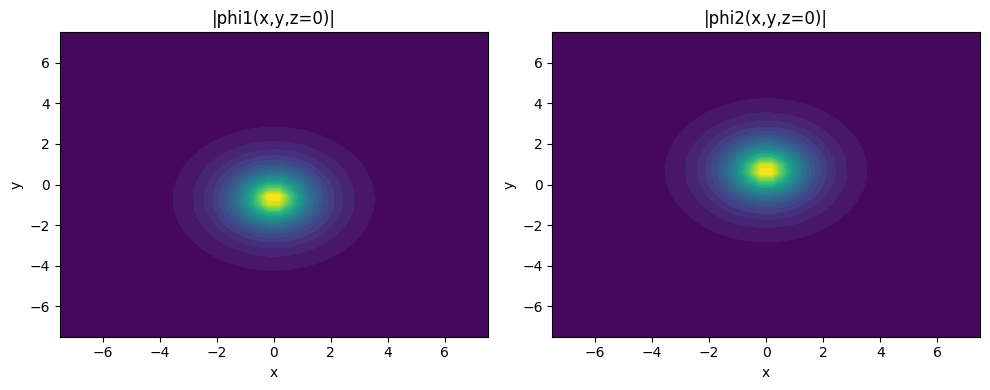

phi1 shape: (64000,) norm: 0.9999999999999997
phi2 shape: (64000,) norm: 0.9999999999999999


In [90]:
import numpy as np
from scipy.special import genlaguerre, sph_harm_y, factorial

def build_hydrogen_wavefunction(n, l, m, N, L, x0=0, y0=0, z0=0, a0=1.0):
    # Build the hydrogen wavefunction on an N x N x N grid.
    # n, l, m are the quantum numbers
    # N is the number of points per dimension
    # L physical length of one side of the cube (centered at origin)
    # The "center" of the orbital can be shifted to (x0, y0, z0). Default is (0, 0, 0).

    # Create uniform Cartesian axis and full 3D mesh.
    axis = np.linspace(-L/2, L/2, N)
    x, y, z = np.meshgrid(axis, axis, axis, indexing='ij')
    #x = x - x0
    #y = y - y0
    #z - z - z0

    # Radial coordinate relative to shifted center (x0,y0,z0).
    r = np.sqrt((x-x0)**2 + (y-y0)**2 + (z-z0)**2)

    # Spherical angles with safe handling at r=0.
    # theta in [0, pi], phi in [-pi, pi].
    theta = np.arccos(np.divide((z-z0), r, out=np.zeros_like(r), where=r!=0))
    phi = np.arctan2((y-y0), (x-x0))

    # Standard hydrogen radial coordinate.
    rho = (2 * r) / (n * a0)

    # Radial normalization coefficient.
    norm_R = np.sqrt((2 / (n * a0))**3 * factorial(n - l - 1) / (2 * n * factorial(n + l)))

    # Associated Laguerre polynomial for hydrogen radial part.
    laguerre = genlaguerre(n - l - 1, 2 * l + 1)

    # Radial factor R_nl(r).
    R_nl = norm_R * np.exp(-rho / 2) * (rho**l) * laguerre(rho)

    # Angular factor Y_lm(theta, phi).
    # scipy sph_harm_y takes (m, l, polar, azimuthal)
    Y_lm = sph_harm_y(m, l, theta, phi)

    # Full wavefunction psi(r) = R_nl(r) * Y_lm(theta, phi).
    psi = R_nl * Y_lm

    # Flatten in C-order to match index mapping used everywhere else.
    # flatten in 'C' order to get index = z + N*y + N**2 * x
    psi = psi.flatten()

    # Normalize in discrete Euclidean norm on the grid.
    return psi / np.linalg.norm(psi)

import matplotlib.pyplot as plt

# c) Build |phi1> and |phi2> as 1s orbitals centered at each nucleus.
N = 40
L = 15

# 1s orbital centered at left nucleus (x=-0.7).
phi1 = build_hydrogen_wavefunction(1,0,0,N,L, x0=-0.7, y0=0, z0=0)

# 1s orbital centered at right nucleus (x=+0.7).
phi2 = build_hydrogen_wavefunction(1,0,0,N,L, x0=0.7, y0=0, z0=0)

# Optional contour check on mid-plane z=0.
axis = np.linspace(-L/2, L/2, N)
mid = N // 2
phi1_3d = phi1.reshape((N, N, N))
phi2_3d = phi2.reshape((N, N, N))

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].contourf(axis, axis, np.abs(phi1_3d[:, :, mid]), levels=30)
ax[0].set_title('|phi1(x,y,z=0)|')
ax[0].set_xlabel('x')
ax[0].set_ylabel('y')

ax[1].contourf(axis, axis, np.abs(phi2_3d[:, :, mid]), levels=30)
ax[1].set_title('|phi2(x,y,z=0)|')
ax[1].set_xlabel('x')
ax[1].set_ylabel('y')

plt.tight_layout()
plt.show()

# Quick checks that vectors are size N^3 and normalized.
print('phi1 shape:', phi1.shape, 'norm:', np.linalg.norm(phi1))
print('phi2 shape:', phi2.shape, 'norm:', np.linalg.norm(phi2))


In [91]:
# d) Build basis transformation matrix S with entries S_mj = <g_m|phi_j>.
# In discrete position basis, each column of S is one basis function sampled
# on all N^3 grid points, ordered with m = k + N*j + N^2*i.

# Column 0 = phi1 values at all grid points.
# Column 1 = phi2 values at all grid points.
S = np.column_stack((phi1, phi2))

# S should be a tall matrix: N^3 rows and 2 columns.
print('S shape:', S.shape)
print('Expected shape:', (N**3, 2))


S shape: (64000, 2)
Expected shape: (64000, 2)


In [92]:
# e) Compute transformed Hamiltonian in the |phi>-basis.

# Hermitian transpose of S (complex-conjugate transpose).
# Needed because phi vectors may be complex from spherical harmonics machinery,
# even when physically real for 1s.
Sdag = S.conj().T

# Project giant position-basis Hamiltonian H into 2D variational subspace:
# H_phi = S^dagger H S.
Hphibasis = Sdag.dot(H.dot(S))

# Report matrix sizes as requested.
print('Hphibasis.shape =', Hphibasis.shape)
print('Hgbasis.shape =', H.shape)


Hphibasis.shape = (2, 2)
Hgbasis.shape = (64000, 64000)


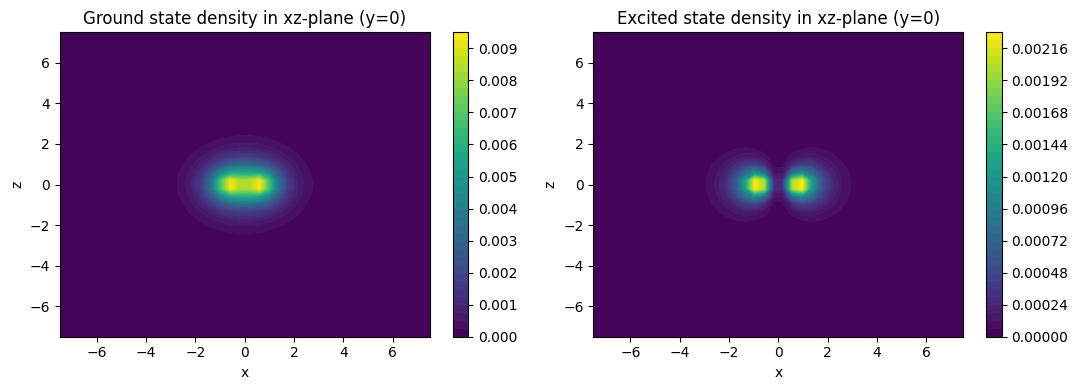

Eigenvalues (ground, excited): [-2.04714825 -0.13885149]
|psi_gs> coefficients (g1, g2): (np.complex128(0.7071067811865474+0j), np.complex128(0.7071067811865476+0j))
|psi_e> coefficients (e1, e2): (np.complex128(-0.7071067811865476+0j), np.complex128(0.7071067811865474+0j))
Lowest state is bonding (in-phase combination).
Chemistry: bonding (sigma) increases electron density between nuclei and lowers energy;
antibonding (sigma*) introduces a node between nuclei and raises energy.


In [93]:
# f) Diagonalize tiny transformed Hamiltonian and visualize eigenstates.

# eigh is for Hermitian matrices; returns sorted eigenvalues (ascending)
# and corresponding orthonormal eigenvectors (columns of U).
E, U = np.linalg.eigh(Hphibasis)

# Ground-state coefficients from first eigenvector column.
g1, g2 = U[:, 0]

# Excited-state coefficients from second eigenvector column.
e1, e2 = U[:, 1]

# Reconstruct full-grid wavefunctions from 2D coefficients.
psi_gs = g1 * phi1 + g2 * phi2
psi_excited = e1 * phi1 + e2 * phi2

# Reshape back to (N,N,N) for slicing/plotting.
psi_gs_3d = psi_gs.reshape((N, N, N))
psi_excited_3d = psi_excited.reshape((N, N, N))

# xz-plane corresponds to y=0 slice (middle index on symmetric grid).
y_mid = N // 2
axis = np.linspace(-L/2, L/2, N)
X, Z = np.meshgrid(axis, axis, indexing='ij')

# Plot probability density, not signed wavefunction, to avoid sign-convention confusion.
gs_density = np.abs(psi_gs_3d[:, y_mid, :])**2
ex_density = np.abs(psi_excited_3d[:, y_mid, :])**2

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
cf1 = ax[0].contourf(X, Z, gs_density, levels=40)
ax[0].set_title('Ground state density in xz-plane (y=0)')
ax[0].set_xlabel('x')
ax[0].set_ylabel('z')
plt.colorbar(cf1, ax=ax[0])

cf2 = ax[1].contourf(X, Z, ex_density, levels=40)
ax[1].set_title('Excited state density in xz-plane (y=0)')
ax[1].set_xlabel('x')
ax[1].set_ylabel('z')
plt.colorbar(cf2, ax=ax[1])

plt.tight_layout()
plt.show()

# Print eigen-information for interpretation.
print('Eigenvalues (ground, excited):', E)
print('|psi_gs> coefficients (g1, g2):', (g1, g2))
print('|psi_e> coefficients (e1, e2):', (e1, e2))

# Sign of g1*g2 indicates relative phase:
# >0 in-phase (bonding), <0 out-of-phase (antibonding).
if np.real(g1 * np.conj(g2)) > 0:
    print('Lowest state is bonding (in-phase combination).')
else:
    print('Lowest state is antibonding (out-of-phase combination).')
    print('If this seems unphysical for H2+, check the sign of V in earlier parts:')
    print('for an electron attracted to two protons, V should be negative.')

print('Chemistry: bonding (sigma) increases electron density between nuclei and lowers energy;')
print('antibonding (sigma*) introduces a node between nuclei and raises energy.')


### Q2(a)
For
$$
|\psi\rangle = c_1|\phi_1\rangle + c_2|\phi_2\rangle,
$$
with real coefficients and normalized basis states
$$
\langle\phi_1|\phi_1\rangle=\langle\phi_2|\phi_2\rangle=1,
$$
and
$$
S_0 = \langle\phi_1|\phi_2\rangle = \langle\phi_2|\phi_1\rangle,
$$
the denominator is
$$
\langle\psi|\psi\rangle
= c_1^2\langle\phi_1|\phi_1\rangle + c_2^2\langle\phi_2|\phi_2\rangle + c_1c_2\langle\phi_1|\phi_2\rangle + c_2c_1\langle\phi_2|\phi_1\rangle
= c_1^2 + c_2^2 + 2c_1c_2S_0.
$$



### Q2(b)
The numerator is
$$
\langle\psi|\hat H|\psi\rangle
= c_1^2\langle\phi_1|\hat H|\phi_1\rangle
+ c_2^2\langle\phi_2|\hat H|\phi_2\rangle
+ c_1c_2\langle\phi_1|\hat H|\phi_2\rangle
+ c_2c_1\langle\phi_2|\hat H|\phi_1\rangle.
$$
Using
$$
H_{11}=\langle\phi_1|\hat H|\phi_1\rangle,\quad
H_{22}=\langle\phi_2|\hat H|\phi_2\rangle,\quad
H_{12}=H_{21},
$$
and real coefficients, this simplifies to
$$
\langle\psi|\hat H|\psi\rangle
= c_1^2 H_{11} + c_2^2 H_{22} + 2c_1c_2 H_{12}.
$$



### Q2(c)
Using parts (a) and (b), define
$$
f(c_1,c_2)=\frac{c_1^2 H_{11}+c_2^2 H_{22}+2c_1c_2H_{12}}{c_1^2+c_2^2+2c_1c_2S_0}.
$$
At the minimum, let
$$
E \equiv f(c_1,c_2),
$$
then setting partial derivatives to zero is equivalent to
$$
\frac{\partial}{\partial c_1}\big(N-ED\big)=0,\qquad
\frac{\partial}{\partial c_2}\big(N-ED\big)=0,
$$
with
$$
N=c_1^2 H_{11}+c_2^2 H_{22}+2c_1c_2H_{12},\qquad
D=c_1^2+c_2^2+2c_1c_2S_0.
$$
This gives the coupled equations
$$
(H_{11}-E)c_1 + (H_{12}-ES_0)c_2 = 0,
$$
$$
(H_{12}-ES_0)c_1 + (H_{22}-E)c_2 = 0.
$$



In [94]:
# Q2(d): helper functions and numerical derivatives df/dc1, df/dc2.
import numpy as np


def minus_E_H(R):
    # Given in prompt: -E_H = -1/2 (Hartree), independent of R.
    # R is accepted as input to keep a uniform function signature.
    return -0.5


def E_H(R):
    # Positive magnitude used inside provided formulas for J.
    return 0.5


def S0(R):
    # Overlap integral between shifted 1s orbitals.
    return np.exp(-R) * (1 + R + (R**2) / 3)


def J(R):
    # Coulomb interaction term supplied in problem statement.
    return E_H(R) * (2 / R) * (1 - (1 + R) * np.exp(-2 * R))


def K(R):
    # Exchange interaction supplied in problem statement.
    return (1 + R) * np.exp(-R)


def H11(R):
    # Diagonal Hamiltonian element from provided relation.
    # H11 = H22 = -E_H - J.
    return minus_E_H(R) - J(R)


def H22(R):
    # Symmetry between nuclei implies equal diagonal elements.
    return H11(R)


def H12(R):
    # Off-diagonal Hamiltonian element from provided relation.
    # H12 = H21 = -E_H*S0 - K.
    return minus_E_H(R) * S0(R) - K(R)


def H21(R):
    # By symmetry, H21 equals H12.
    return H12(R)


def delf_dc1(c1, c2, R):
    # Compute derivative wrt c1 of f = N/D using quotient rule.

    # Precompute constants at this R.
    h11 = H11(R)
    h22 = H22(R)
    h12 = H12(R)
    s0 = S0(R)

    # Numerator N = <psi|H|psi> in two-state basis.
    N = c1**2 * h11 + c2**2 * h22 + 2 * c1 * c2 * h12

    # Denominator D = <psi|psi> with non-orthogonal overlap.
    D = c1**2 + c2**2 + 2 * c1 * c2 * s0

    # Partial derivatives needed by quotient rule.
    dN_dc1 = 2 * c1 * h11 + 2 * c2 * h12
    dD_dc1 = 2 * c1 + 2 * c2 * s0

    # df/dc1 = (dN*D - N*dD) / D^2.
    return (dN_dc1 * D - N * dD_dc1) / (D**2)


def delf_dc2(c1, c2, R):
    # Compute derivative wrt c2 of f = N/D using quotient rule.

    # Precompute constants at this R.
    h11 = H11(R)
    h22 = H22(R)
    h12 = H12(R)
    s0 = S0(R)

    # Numerator and denominator definitions reused.
    N = c1**2 * h11 + c2**2 * h22 + 2 * c1 * c2 * h12
    D = c1**2 + c2**2 + 2 * c1 * c2 * s0

    # Partial derivatives wrt c2.
    dN_dc2 = 2 * c2 * h22 + 2 * c1 * h12
    dD_dc2 = 2 * c2 + 2 * c1 * s0

    # df/dc2 = (dN*D - N*dD) / D^2.
    return (dN_dc2 * D - N * dD_dc2) / (D**2)


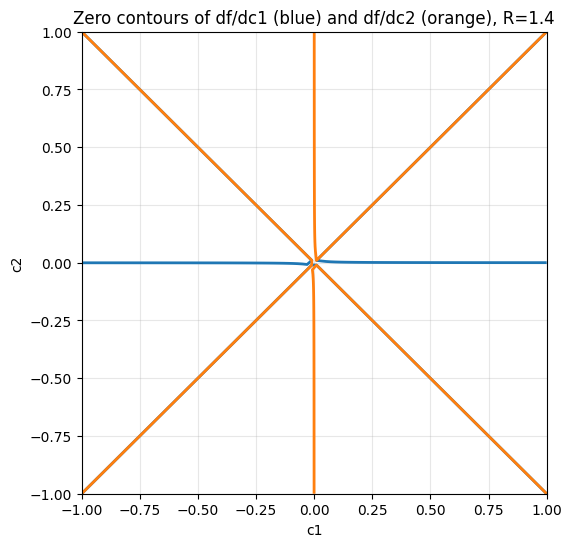

Approximate stationary solutions from contour intersection:
c1=-1.0000, c2=-1.0000, normalization=<psi|psi>=3.505885
c1=-1.0000, c2=-0.9394, normalization=<psi|psi>=3.297081
c1=-1.0000, c2=-0.8788, normalization=<psi|psi>=3.095622
c1=-1.0000, c2=1.0000, normalization=<psi|psi>=0.494115
c1=-0.9798, c2=-0.8182, normalization=<psi|psi>=2.836623
c1=-0.9596, c2=0.9596, normalization=<psi|psi>=0.454993
c1=-0.9394, c2=-1.0000, normalization=<psi|psi>=3.297081
c1=-0.9394, c2=-0.9394, normalization=<psi|psi>=3.093807
c1=-0.9394, c2=-0.8788, normalization=<psi|psi>=2.897880
c1=-0.9192, c2=-0.8182, normalization=<psi|psi>=2.646861
c1=-0.9192, c2=0.9192, normalization=<psi|psi>=0.417484
c1=-0.8990, c2=-0.7576, normalization=<psi|psi>=2.407692
c1=-0.8788, c2=-1.0000, normalization=<psi|psi>=3.095622
c1=-0.8788, c2=-0.9394, normalization=<psi|psi>=2.897880
c1=-0.8788, c2=-0.8788, normalization=<psi|psi>=2.707484
c1=-0.8788, c2=0.8788, normalization=<psi|psi>=0.381589
c1=-0.8586, c2=-0.8182, normaliz

In [95]:
# Q2(e): contour method at fixed internuclear separation R=1.4.
import numpy as np
import matplotlib.pyplot as plt

# Fixed bond length requested by prompt.
R = 1.4

# Build coefficient scan grid: 100 values in (-1,1) for each coefficient.
c1_vals = np.linspace(-1, 1, 100)
c2_vals = np.linspace(-1, 1, 100)

# 2D mesh where each point corresponds to one (c1,c2) pair.
C1, C2 = np.meshgrid(c1_vals, c2_vals, indexing='ij')

# Evaluate derivative fields over entire grid.
DF1 = delf_dc1(C1, C2, R)
DF2 = delf_dc2(C1, C2, R)

# Plot zero contours for both derivatives.
# Intersections represent candidate stationary points.
plt.figure(figsize=(6, 6))
cs1 = plt.contour(c1_vals, c2_vals, DF1.T, levels=[0], colors='tab:blue', linewidths=2)
cs2 = plt.contour(c1_vals, c2_vals, DF2.T, levels=[0], colors='tab:orange', linewidths=2)
plt.xlabel('c1')
plt.ylabel('c2')
plt.title('Zero contours of df/dc1 (blue) and df/dc2 (orange), R=1.4')
plt.grid(alpha=0.3)
plt.show()

# Identify approximate grid points where both derivatives are near zero.
# Threshold is numerical tolerance, not exact analytic equality.
thresh = 1e-2
mask = (np.abs(DF1) < thresh) & (np.abs(DF2) < thresh)
pts = np.column_stack([C1[mask], C2[mask]])

# Remove near-duplicates so printout is readable.
unique_pts = []
for p in pts:
    if not unique_pts:
        unique_pts.append(p)
    else:
        d = np.linalg.norm(np.array(unique_pts) - p, axis=1)
        if np.min(d) > 0.05:
            unique_pts.append(p)

print('Approximate stationary solutions from contour intersection:')
for p in unique_pts:
    c1, c2 = p
    norm = c1**2 + c2**2 + 2*c1*c2*S0(R)
    print(f'c1={c1:.4f}, c2={c2:.4f}, normalization=<psi|psi>={norm:.6f}')

# Analytic normalized candidates for symmetric and antisymmetric branches.
s0 = S0(R)
c_sym = 1.0 / np.sqrt(2*(1+s0))
c_asym = 1.0 / np.sqrt(2*(1-s0))

print('\nNormalized analytic candidates:')
print(f'Bonding candidate:     (c1, c2)=({c_sym:.6f}, {c_sym:.6f}),  <psi|psi>={c_sym**2 + c_sym**2 + 2*c_sym*c_sym*s0:.6f}')
print(f'Antibonding candidate: (c1, c2)=({c_asym:.6f}, {-c_asym:.6f}), <psi|psi>={c_asym**2 + c_asym**2 - 2*c_asym*c_asym*s0:.6f}')


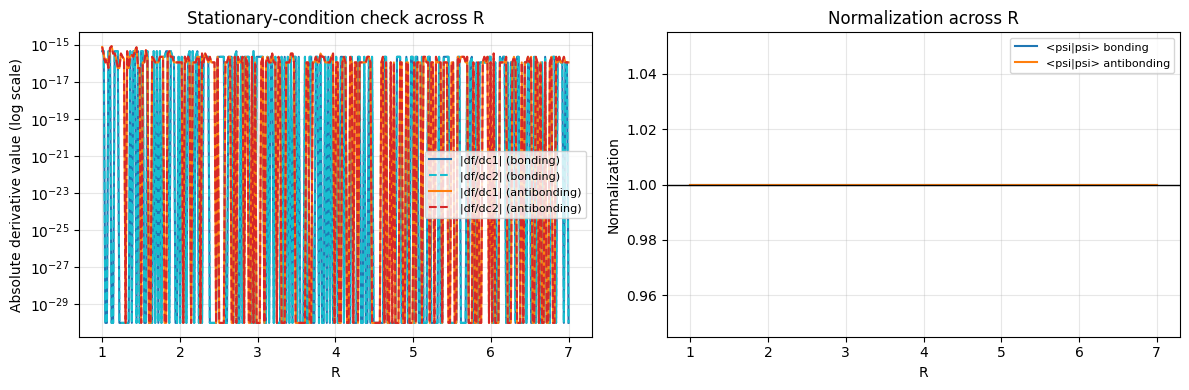

Max |df/dc1| bonding: 4.440892098500628e-16
Max |df/dc2| bonding: 4.440892098500628e-16
Max |df/dc1| antibonding: 8.326672684688674e-16
Max |df/dc2| antibonding: 8.326672684688674e-16
Max |<psi|psi>-1| bonding: 4.440892098500626e-16
Max |<psi|psi>-1| antibonding: 4.440892098500626e-16


In [96]:
# Q2(f): verify stationary solutions for a continuous range R in (1, 7).
import numpy as np
import matplotlib.pyplot as plt

# Sample R values densely to get smooth curves.
R_vals = np.linspace(1.0, 7.0, 300)

# Overlap S0 at each R.
S_vals = S0(R_vals)

# Normalized symmetric branch (bonding): c1=c2.
c_sym = 1.0 / np.sqrt(2.0 * (1.0 + S_vals))

# Normalized antisymmetric branch (antibonding): c1=-c2.
c_asym = 1.0 / np.sqrt(2.0 * (1.0 - S_vals))

# Evaluate stationarity derivatives on both branches.
sym_df1 = delf_dc1(c_sym, c_sym, R_vals)
sym_df2 = delf_dc2(c_sym, c_sym, R_vals)

asym_df1 = delf_dc1(c_asym, -c_asym, R_vals)
asym_df2 = delf_dc2(c_asym, -c_asym, R_vals)

# Verify normalization remains exactly 1 (up to floating-point error).
norm_sym = c_sym**2 + c_sym**2 + 2*c_sym*c_sym*S_vals
norm_asym = c_asym**2 + c_asym**2 + 2*c_asym*(-c_asym)*S_vals

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Log-scale residual plot: values are tiny, so linear scale hides structure.
eps = 1e-30
ax[0].plot(R_vals, np.abs(sym_df1) + eps, label='|df/dc1| (bonding)', color='tab:blue')
ax[0].plot(R_vals, np.abs(sym_df2) + eps, '--', label='|df/dc2| (bonding)', color='tab:cyan')
ax[0].plot(R_vals, np.abs(asym_df1) + eps, label='|df/dc1| (antibonding)', color='tab:orange')
ax[0].plot(R_vals, np.abs(asym_df2) + eps, '--', label='|df/dc2| (antibonding)', color='tab:red')
ax[0].set_yscale('log')
ax[0].set_xlabel('R')
ax[0].set_ylabel('Absolute derivative value (log scale)')
ax[0].set_title('Stationary-condition check across R')
ax[0].grid(alpha=0.3, which='both')
ax[0].legend(fontsize=8)

# Normalization plot for both branches.
ax[1].plot(R_vals, norm_sym, label='<psi|psi> bonding', color='tab:blue')
ax[1].plot(R_vals, norm_asym, label='<psi|psi> antibonding', color='tab:orange')
ax[1].axhline(1.0, color='k', linewidth=1)
ax[1].set_xlabel('R')
ax[1].set_ylabel('Normalization')
ax[1].set_title('Normalization across R')
ax[1].grid(alpha=0.3)
ax[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

# Print compact numerical diagnostics.
print('Max |df/dc1| bonding:', np.max(np.abs(sym_df1)))
print('Max |df/dc2| bonding:', np.max(np.abs(sym_df2)))
print('Max |df/dc1| antibonding:', np.max(np.abs(asym_df1)))
print('Max |df/dc2| antibonding:', np.max(np.abs(asym_df2)))
print('Max |<psi|psi>-1| bonding:', np.max(np.abs(norm_sym - 1.0)))
print('Max |<psi|psi>-1| antibonding:', np.max(np.abs(norm_asym - 1.0)))


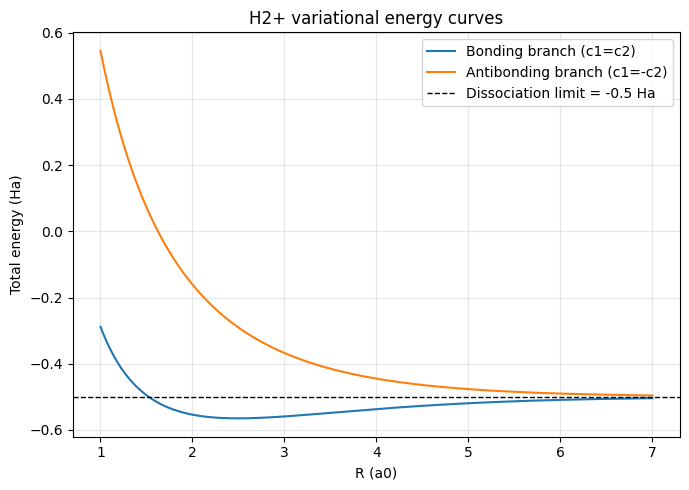

E_bonding(R=7)  = -0.5040347034512007
E_antibond(R=7) = -0.4957802364891499
Reference dissociation value: -0.5 Ha (magnitude 0.5)


In [97]:
# Q2(g): total energy function and dissociation curves.
import numpy as np
import matplotlib.pyplot as plt


def energy_total(c1, c2, R):
    # Build Hamiltonian matrix elements and overlap at this R.
    h11 = H11(R)
    h22 = H22(R)
    h12 = H12(R)
    s0 = S0(R)

    # Variational electronic energy numerator and denominator.
    num = c1**2 * h11 + c2**2 * h22 + 2 * c1 * c2 * h12
    den = c1**2 + c2**2 + 2 * c1 * c2 * s0

    # Add nuclear-nuclear repulsion term +1/R to electronic contribution.
    return num / den + 1.0 / R


# Define R scan used for dissociation curve.
R_vals = np.linspace(1.0, 7.0, 400)
S_vals = S0(R_vals)

# Two normalized stationary branches from previous parts.
c_sym = 1.0 / np.sqrt(2.0 * (1.0 + S_vals))
c_asym = 1.0 / np.sqrt(2.0 * (1.0 - S_vals))

# Evaluate total energy on both branches.
E_sym = energy_total(c_sym, c_sym, R_vals)
E_asym = energy_total(c_asym, -c_asym, R_vals)

# Plot dissociation curves.
plt.figure(figsize=(7, 5))
plt.plot(R_vals, E_sym, label='Bonding branch (c1=c2)', color='tab:blue')
plt.plot(R_vals, E_asym, label='Antibonding branch (c1=-c2)', color='tab:orange')

# Reference horizontal line: hydrogen 1s limit at -0.5 Ha.
plt.axhline(-0.5, color='k', linestyle='--', linewidth=1, label='Dissociation limit = -0.5 Ha')
plt.xlabel('R (a0)')
plt.ylabel('Total energy (Ha)')
plt.title('H2+ variational energy curves')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Print endpoint checks near large-R side of scan.
print('E_bonding(R=7)  =', E_sym[-1])
print('E_antibond(R=7) =', E_asym[-1])
print('Reference dissociation value: -0.5 Ha (magnitude 0.5)')


### Q2(g) Explanations
(i) Physical meaning of the two curves:
- The lower curve (from \(c_1=c_2\)) is the bonding \(\sigma_g\)-like combination. It has constructive overlap between nuclei, increases electron density in the internuclear region, and lowers energy.
- The upper curve (from \(c_1=-c_2\)) is the antibonding \(\sigma_u^*\)-like combination. It has a node between nuclei, reduces density in the bonding region, and raises energy.

(ii) Why the dissociation-limit energy is 0.5:
- In atomic units, the hydrogen 1s energy is \(-0.5\) Ha.
- As \(R\to\infty\), overlap/exchange vanish (\(S_0\to0\), \(K\to0\)) and proton-proton repulsion vanishes (\(1/R\to0\)), so the molecule becomes a neutral H atom plus a far proton.
- Therefore the total energy tends to \(-0.5\) Ha. If one states "0.5" they mean the magnitude of that asymptotic hydrogen energy.

